In [1]:
import torch
from torch import nn

**【问题 2.1.5A (mixed_precision_accumulation): 混合精度累加 (1分)】**

In [2]:
s = torch.tensor(0, dtype=torch.float32)
for i in range(1000):
    s += torch.tensor(0.01, dtype=torch.float32)
print(s)

s = torch.tensor(0, dtype=torch.float16)
for i in range(1000):
    s += torch.tensor(0.01, dtype=torch.float16)
print(s)

s = torch.tensor(0, dtype=torch.float32)
for i in range(1000):
    s += torch.tensor(0.01, dtype=torch.float16)
print(s)

s = torch.tensor(0, dtype=torch.float32)
for i in range(1000):
    x = torch.tensor(0.01, dtype=torch.float16)
    s += x.type(torch.float32)
print(s)

tensor(10.0001)
tensor(9.9531, dtype=torch.float16)
tensor(10.0021)
tensor(10.0021)


**【问题 2.1.5B (benchmarking_mixed_precision): 基准测试混合精度 (2分)】**

In [8]:
class ToyModel(nn.Module):
    def __init__(self, in_features: int, out_features: int):
        super().__init__()
        self.fc1 = nn.Linear(in_features, 10, bias=False)
        self.ln = nn.LayerNorm(10)
        self.fc2 = nn.Linear(10, out_features, bias=False)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.ln(x)
        x = self.fc2(x)
        return x

**(a)**

假设我们在 GPU 上训练模型，并且模型参数最初是 FP32。我们想使用 FP16 的自动混合精度（autocasting）。

请问以下组件的数据类型是什么：

- autocast 上下文中的模型参数？
    > FP32
    >
    > `autocast` 不会改变模型参数本身的存储类型（权重仍然是 FP32 存在显存里）。
    >
    > 只在计算发生的一瞬间，PyTorch 会把权重临时转成 FP16 给 Tensor Core 用，用完就扔（或者缓存），**权重本身永远是 FP32**。

- 第一个前馈层（ToyModel.fc1）的输出？
    > FP16

- LayerNorm 层（ToyModel.ln）的输出？
    > FP32

- 模型预测的 logits？
    > **FP16**：因为在模型最后一步经过了 Linear 层，由于 matmul 采用 FP16 精度，所以输出也是 FP16。

- 损失（loss）？
    > FP32

- 模型的梯度（gradients）？
    > FP32
    >
    > 模型参数是 FP32，反向传播时计算出来的 param.grad 必须和参数保持相同的类型，所以是 FP32。
    >
    > 优化器（如 AdamW）更新时也是用 FP32 更新。

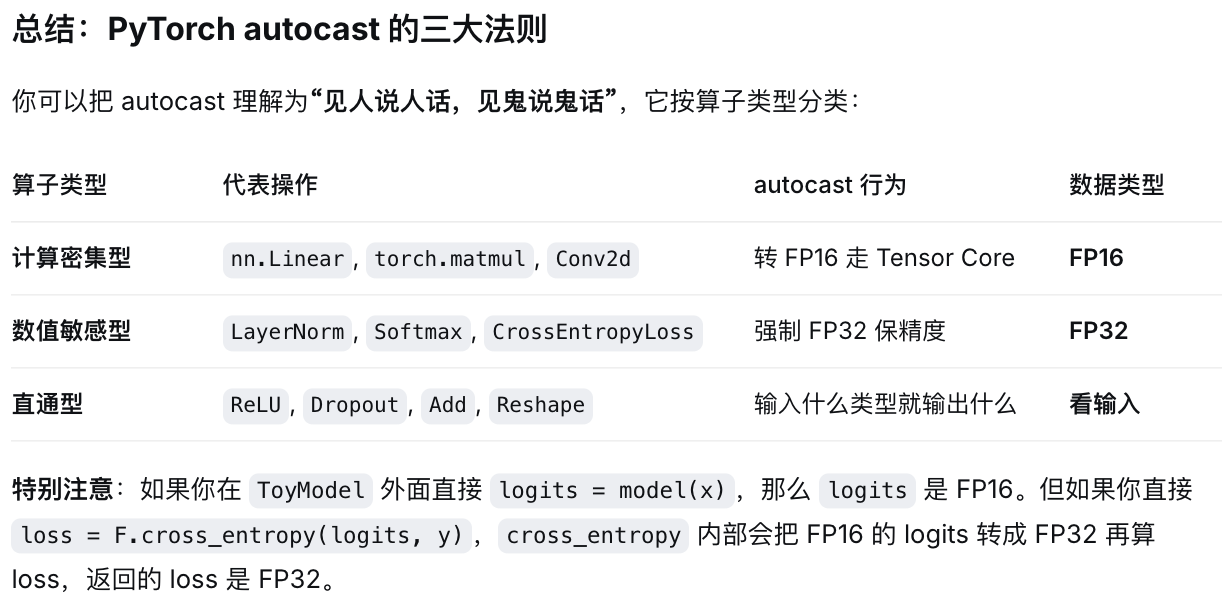  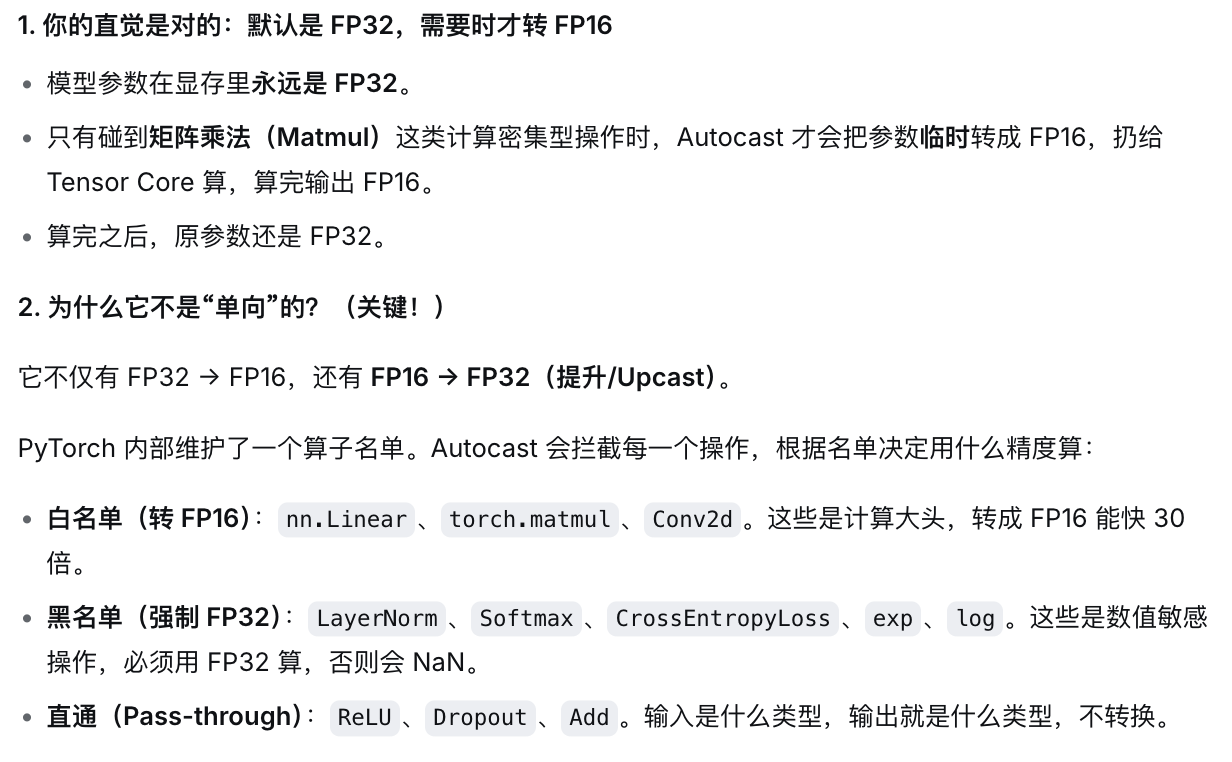

**(b)**

FP16 混合精度自动转换（autocasting）对 LayerNorm 层的处理与前馈层不同。

LayerNorm 的哪些部分对混合精度敏感？如果我们使用 BF16 而不是 FP16，我们还需要区别对待 LayerNorm 吗？为什么需要或为什么不需要？

> LayerNorm 中
>
>
>
>